going to get looking at some data

In [1]:
import pandas as pd
import numpy as np

big_data_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\2015-2025jSPXoptions.csv"

big_data = pd.read_csv(big_data_filepath)



In [2]:
# Inspect data structure
print("Dataset shape:", big_data.shape)
print("\nColumn names and types:")
print(big_data.info())
print("\nFirst few rows:")
print(big_data.head(5))
print("\nBasic statistics:")
print(big_data.describe())
print("\nData types:")
print(big_data.dtypes)
print("\nMissing values:")
print(big_data.isnull().sum())

Dataset shape: (42225530, 23)

Column names and types:
<class 'pandas.DataFrame'>
RangeIndex: 42225530 entries, 0 to 42225529
Data columns (total 23 columns):
 #   Column            Dtype  
---  ------            -----  
 0   secid             int64  
 1   date              str    
 2   symbol            str    
 3   exdate            str    
 4   cp_flag           str    
 5   strike_price      int64  
 6   best_bid          float64
 7   best_offer        float64
 8   volume            int64  
 9   open_interest     int64  
 10  impl_volatility   float64
 11  delta             float64
 12  gamma             float64
 13  vega              float64
 14  theta             float64
 15  optionid          int64  
 16  forward_price     float64
 17  expiry_indicator  str    
 18  index_flag        int64  
 19  issue_type        str    
 20  industry_group    float64
 21  issuer            str    
 22  exercise_style    str    
dtypes: float64(9), int64(6), str(8)
memory usage: 7.2 GB
None

Fi

In [3]:
columns_to_keep = ["secid", "date", "exdate", "cp_flag", "strike_price", "best_bid", "best_offer",
                    "optionid", "exercise_style", "delta", "vega", "gamma", "impl_volatility"]

filtered_data = big_data[columns_to_keep]
# Rename strike_price to K and divide by 1000
filtered_data = filtered_data.rename(columns={'strike_price': 'K'})
filtered_data['K'] = filtered_data['K'] / 1000

print(filtered_data.head(5))

#about equal number of calls and puts
#only european options

    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  02/01/2015  17/01/2015       C   100.0    1956.4      1959.6   
1  108105  02/01/2015  17/01/2015       C  1000.0    1056.7      1059.9   
2  108105  02/01/2015  17/01/2015       C  1025.0    1031.7      1034.9   
3  108105  02/01/2015  17/01/2015       C  1050.0    1006.7      1009.8   
4  108105  02/01/2015  17/01/2015       C  1075.0     981.7       984.8   

    optionid exercise_style     delta      vega     gamma  impl_volatility  
0  101234071              E       NaN       NaN       NaN              NaN  
1  101234072              E  0.999103  1.179546  0.000006         1.222229  
2  101234073              E  0.999083  1.204660  0.000006         1.181493  
3  101234074              E  0.999391  0.808892  0.000005         1.092237  
4  101234075              E  0.999382  0.820990  0.000005         1.054338  


In [4]:
# Convert date column to datetime format (dd/mm/yyyy)
filtered_data['date'] = pd.to_datetime(filtered_data['date'], format='%d/%m/%Y')
filtered_data['exdate'] = pd.to_datetime(filtered_data['exdate'], format='%d/%m/%Y')

# Filter data to only include dates between 02/16/2015 and 01/07/2021
cutoff_date_start = pd.to_datetime('2015-10-16')
cutoff_date_end = pd.to_datetime('2021-07-01')
filtered_data = filtered_data[(filtered_data['date'] >= cutoff_date_start) & (filtered_data['date'] < cutoff_date_end)]

print(f"Dataset shape after date filter: {filtered_data.shape}")
print(f"\nDate range: {filtered_data['date'].min()} to {filtered_data['date'].max()}")
print(f"\nFirst few rows:")
print(filtered_data.head())

Dataset shape after date filter: (18194288, 13)

Date range: 2015-10-16 00:00:00 to 2021-06-30 00:00:00

First few rows:
          secid       date     exdate cp_flag       K  best_bid  best_offer  \
1561744  108105 2015-10-16 2015-11-20       C  1000.0    1025.3      1030.0   
1561745  108105 2015-10-16 2015-11-20       C  1025.0    1000.4      1005.0   
1561746  108105 2015-10-16 2015-11-20       C  1050.0     975.4       980.0   
1561747  108105 2015-10-16 2015-11-20       C  1075.0     950.4       955.1   
1561748  108105 2015-10-16 2015-11-20       C  1100.0     925.4       930.1   

          optionid exercise_style     delta      vega     gamma  \
1561744  108485570              E  0.996078  2.218131  0.000007   
1561745  108485571              E  0.995777  2.784215  0.000009   
1561746  108485572              E  0.995758  2.818352  0.000010   
1561747  108485573              E  0.995439  3.404782  0.000012   
1561748  108485574              E  0.995409  3.459122  0.000013   

 

In [5]:
# Load SPX price data
spx_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\S&P 500 Historical Data 2015-2022.csv"  # Update filename if needed

spx_data = pd.read_csv(spx_filepath)

# Convert SPX date column to datetime format (mm/dd/yyyy)
spx_data['Date'] = pd.to_datetime(spx_data['Date'], format='%m/%d/%Y')

# Convert both date columns to date only (removing time component) for proper merging
# First ensure filtered_data['date'] is datetime before converting
if not pd.api.types.is_datetime64_any_dtype(filtered_data['date']):
    filtered_data['date'] = pd.to_datetime(filtered_data['date'])
    
filtered_data['date'] = filtered_data['date'].dt.date
filtered_data['exdate'] = filtered_data['exdate'].dt.date
spx_data['Date'] = spx_data['Date'].dt.date

print(spx_data.head())

# Merge filtered_data with spx_data on date columns
filtered_data = filtered_data.merge(spx_data[['Date', 'Price']], 
                                    left_on='date', 
                                    right_on='Date', 
                                    how='left')

# Rename 'Price' to 'S' and drop the duplicate 'Date' column
filtered_data = filtered_data.rename(columns={'Price': 'S'})
filtered_data = filtered_data.drop(columns=['Date'])



# Remove duplicate S columns, keeping only the first one
s_columns = [col for col in filtered_data.columns if col == 'S']
if len(s_columns) > 1:
    # Get all columns and remove duplicates
    filtered_data = filtered_data.loc[:, ~filtered_data.columns.duplicated(keep='first')]
    print("Removed duplicate columns")

print("Merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nFirst few rows:")
print(filtered_data.head())

         Date    Price      Open      High       Low  Vol. Change %
0  2025-10-03  6715.79  6,722.14  6,750.87  6,705.67   NaN    0.01%
1  2025-10-02  6715.35  6,731.31  6,731.94  6,693.23   NaN    0.06%
2  2025-10-01  6711.20  6,664.92  6,718.48  6,656.20   NaN    0.34%
3  2025-09-30  6688.46  6,656.19  6,691.25  6,641.00   NaN    0.41%
4  2025-09-29  6661.21  6,661.58  6,677.31  6,644.49   NaN    0.26%
Merge complete!
Filtered data shape: (18194288, 14)

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2015-10-16  2015-11-20       C  1000.0    1025.3      1030.0   
1  108105  2015-10-16  2015-11-20       C  1025.0    1000.4      1005.0   
2  108105  2015-10-16  2015-11-20       C  1050.0     975.4       980.0   
3  108105  2015-10-16  2015-11-20       C  1075.0     950.4       955.1   
4  108105  2015-10-16  2015-11-20       C  1100.0     925.4       930.1   

    optionid exercise_style     delta      vega     gamma  impl_volatili

In [6]:
vix_filepath = r"C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Data\Full_VIX_History.csv"  # Update filename if needed

vix_data = pd.read_csv(vix_filepath)

# Convert VIX date column to datetime format (mm/dd/yyyy)
vix_data['DATE'] = pd.to_datetime(vix_data['DATE'], format='%m/%d/%Y')

# Convert DATE to date only (removing time component) to match filtered_data['date']
vix_data['DATE'] = vix_data['DATE'].dt.date


print(vix_data.head())

# Merge filtered_data with vix_data on date columns
filtered_data = filtered_data.merge(vix_data[['DATE', 'CLOSE']], 
                                    left_on='date', 
                                    right_on='DATE', 
                                    how='left')

# Rename 'CLOSE' to 'sigma' and drop the duplicate 'DATE' column
filtered_data = filtered_data.rename(columns={'CLOSE': 'sigma'})
filtered_data = filtered_data.drop(columns=['DATE'])

#turn sigma into percentage
filtered_data['sigma'] = filtered_data['sigma'] / 100

print("Merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nFirst few rows:")
print(filtered_data.head())

         DATE   OPEN   HIGH    LOW  CLOSE
0  1990-01-02  17.24  17.24  17.24  17.24
1  1990-01-03  18.19  18.19  18.19  18.19
2  1990-01-04  19.22  19.22  19.22  19.22
3  1990-01-05  20.11  20.11  20.11  20.11
4  1990-01-08  20.26  20.26  20.26  20.26
Merge complete!
Filtered data shape: (18194288, 15)

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2015-10-16  2015-11-20       C  1000.0    1025.3      1030.0   
1  108105  2015-10-16  2015-11-20       C  1025.0    1000.4      1005.0   
2  108105  2015-10-16  2015-11-20       C  1050.0     975.4       980.0   
3  108105  2015-10-16  2015-11-20       C  1075.0     950.4       955.1   
4  108105  2015-10-16  2015-11-20       C  1100.0     925.4       930.1   

    optionid exercise_style     delta      vega     gamma  impl_volatility  \
0  108485570              E  0.996078  2.218131  0.000007         0.785110   
1  108485571              E  0.995777  2.784215  0.000009         0.7771

In [7]:
#want to add interest rates now!!!
interestrate_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\yield-curve-rates-2015-2025.csv"  # Update filename if needed

ir_data = pd.read_csv(interestrate_filepath)

def parse_mixed_date(date_str):
    try:
        # Try mm/dd/yyyy format first
        return pd.to_datetime(date_str, format='%m/%d/%Y')
    except:
        try:
            # Fall back to mm/dd/yy format
            return pd.to_datetime(date_str, format='%m/%d/%y')
        except:
            print(f"Unrecognized date format: {date_str}")

ir_data['Date'] = ir_data['Date'].apply(parse_mixed_date).dt.date

# Rename columns
ir_data = ir_data.rename(columns={
    '1 Mo': 'r 1 Mo',
    '3 Mo': 'r 3 Mo',
    '6 Mo': 'r 6 Mo'
})

# Merge interest rate data with filtered_data
filtered_data = filtered_data.merge(ir_data[['Date', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']], 
                                    left_on='date', 
                                    right_on='Date', 
                                    how='left')

# Drop the duplicate Date column
filtered_data = filtered_data.drop(columns=['Date'])

rate_cols = ['r 1 Mo', 'r 3 Mo', 'r 6 Mo']

# strip weird characters and coerce to numbers
for c in rate_cols:
    filtered_data[c] = (
        filtered_data[c]
        .astype(str)
        .str.replace('%','', regex=False)
        .str.replace(',','', regex=False)
        .str.strip()
    )
    filtered_data[c] = pd.to_numeric(filtered_data[c], errors='coerce')

# now divide by 100 (if the values are in percent units like 5.25)
filtered_data[rate_cols] = filtered_data[rate_cols] / 100


print("Interest rate merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"Columns: {list(filtered_data.columns)}")
print(f"\nFirst few rows:")
print(filtered_data.head())



Interest rate merge complete!
Filtered data shape: (18194288, 18)
Columns: ['secid', 'date', 'exdate', 'cp_flag', 'K', 'best_bid', 'best_offer', 'optionid', 'exercise_style', 'delta', 'vega', 'gamma', 'impl_volatility', 'S', 'sigma', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2015-10-16  2015-11-20       C  1000.0    1025.3      1030.0   
1  108105  2015-10-16  2015-11-20       C  1025.0    1000.4      1005.0   
2  108105  2015-10-16  2015-11-20       C  1050.0     975.4       980.0   
3  108105  2015-10-16  2015-11-20       C  1075.0     950.4       955.1   
4  108105  2015-10-16  2015-11-20       C  1100.0     925.4       930.1   

    optionid exercise_style     delta      vega     gamma  impl_volatility  \
0  108485570              E  0.996078  2.218131  0.000007         0.785110   
1  108485571              E  0.995777  2.784215  0.000009         0.777109   
2  108485572              E  0.995

In [8]:
# Convert S and K to numeric types
filtered_data['S'] = pd.to_numeric(filtered_data['S'], errors='coerce')
filtered_data['K'] = pd.to_numeric(filtered_data['K'], errors='coerce')

# Convert date columns back to datetime for arithmetic operations
filtered_data['date'] = pd.to_datetime(filtered_data['date'])
filtered_data['exdate'] = pd.to_datetime(filtered_data['exdate'])

# Calculate new columns
# mid: midpoint of bid-ask spread
filtered_data['mid'] = (filtered_data['best_bid'] + filtered_data['best_offer']) / 2

# T: time to expiration in years
filtered_data['T'] = (filtered_data['exdate'] - filtered_data['date']).dt.days / 365.0

# Log-moneyness: log(S/K)
filtered_data['log_moneyness'] = np.log(filtered_data['S'] / filtered_data['K'])

# Remove duplicate S columns, keeping only the first one
s_columns = [col for col in filtered_data.columns if col == 'S']
if len(s_columns) > 1:
    # Get all columns and remove duplicates
    filtered_data = filtered_data.loc[:, ~filtered_data.columns.duplicated(keep='first')]
    print("Removed duplicate columns")

# Debug: Check cp_flag values before mapping
print("cp_flag values before mapping:")
print(filtered_data['cp_flag'].unique())
print(f"cp_flag data type: {filtered_data['cp_flag'].dtype}")
print(f"cp_flag null count: {filtered_data['cp_flag'].isnull().sum()}")

filtered_data["cp_flag"] = filtered_data["cp_flag"].map({"C": 1, "P": 0})

print("\nNew columns created!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nColumns: {list(filtered_data.columns)}")
print(f"\nFirst few rows:")
print(filtered_data.head())
print(filtered_data.tail())

# Print unique cp_flag values
print("\nUnique cp_flag values in training data:", filtered_data['cp_flag'].unique())
print("Unique cp_flag values in test data:", filtered_data['cp_flag'].unique())





cp_flag values before mapping:
<StringArray>
['C', 'P']
Length: 2, dtype: str
cp_flag data type: str
cp_flag null count: 0

New columns created!
Filtered data shape: (18194288, 21)

Columns: ['secid', 'date', 'exdate', 'cp_flag', 'K', 'best_bid', 'best_offer', 'optionid', 'exercise_style', 'delta', 'vega', 'gamma', 'impl_volatility', 'S', 'sigma', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo', 'mid', 'T', 'log_moneyness']

First few rows:
    secid       date     exdate  cp_flag       K  best_bid  best_offer  \
0  108105 2015-10-16 2015-11-20        1  1000.0    1025.3      1030.0   
1  108105 2015-10-16 2015-11-20        1  1025.0    1000.4      1005.0   
2  108105 2015-10-16 2015-11-20        1  1050.0     975.4       980.0   
3  108105 2015-10-16 2015-11-20        1  1075.0     950.4       955.1   
4  108105 2015-10-16 2015-11-20        1  1100.0     925.4       930.1   

    optionid exercise_style     delta  ...     gamma  impl_volatility       S  \
0  108485570              E  0.996078  ...  0.00

In [9]:
#putting in Black scholes price for feature
from math import erf, sqrt

def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def bs_price_row(S, K, T, r, sigma, cp_flag):
    # Basic guards
    if not np.isfinite(S) or not np.isfinite(K) or not np.isfinite(T) or not np.isfinite(r) or not np.isfinite(sigma):
        return np.nan
    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return np.nan

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if cp_flag == 1:  # Call
        return S * norm_cdf(d1) - K * np.exp(-r * T) * norm_cdf(d2)
    else:            # Put
        return K * np.exp(-r * T) * norm_cdf(-d2) - S * norm_cdf(-d1)

# Choose your rate column
r_col = "r 3 Mo"

# Ensure rate is decimal (uncomment if your rates are in percent units)
# filtered_data[r_col] = filtered_data[r_col] / 100.0

# Compute BS price
filtered_data["bs_price"] = filtered_data.apply(
    lambda row: bs_price_row(row["S"], row["K"], row["T"], row[r_col], row["sigma"], row["cp_flag"]),
    axis=1
)

print("Added bs_price column.")
print(filtered_data[["S","K","T",r_col,"sigma","cp_flag","mid","bs_price", 'delta', "vega", "gamma", "impl_volatility"]].head())

Added bs_price column.
        S       K        T  r 3 Mo   sigma  cp_flag      mid     bs_price  \
0  2033.1  1000.0  0.09589  0.0001  0.1505        1  1027.65  1033.109589   
1  2033.1  1025.0  0.09589  0.0001  0.1505        1  1002.70  1008.109829   
2  2033.1  1050.0  0.09589  0.0001  0.1505        1   977.70   983.110068   
3  2033.1  1075.0  0.09589  0.0001  0.1505        1   952.75   958.110308   
4  2033.1  1100.0  0.09589  0.0001  0.1505        1   927.75   933.110548   

      delta      vega     gamma  impl_volatility  
0  0.996078  2.218131  0.000007         0.785110  
1  0.995777  2.784215  0.000009         0.777109  
2  0.995758  2.818352  0.000010         0.749627  
3  0.995439  3.404782  0.000012         0.738809  
4  0.995409  3.459122  0.000013         0.712394  


In [11]:
# # Check if optionid 134606380 exists in the dataset
# target_id = 134606380
# if target_id in filtered_data['optionid'].values:
#     print(f"Found optionid {target_id}!")
#     print("\nRow(s) with this optionid:")
#     print(filtered_data[filtered_data['optionid'] == target_id])
# else:
#     print(f"optionid {target_id} NOT found in the dataset")

should probs build test data set before moving on


In [74]:
#option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\30day134606830.csv"
# option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\moneyness\\DeepITMoption.csv"
option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\yearlongatmoption.csv"

option = pd.read_csv(option_filepath)

# Convert dates to datetime and then to date for merging
option['date'] = pd.to_datetime(option['date'], format='%d/%m/%Y').dt.date
option['exdate'] = pd.to_datetime(option['exdate'], format='%d/%m/%Y')

# Rename strike_price to K and divide by 1000
option = option.rename(columns={'strike_price': 'K'})
option['K'] = option['K'] / 1000

option["cp_flag"] = "C"

# Merge with SPX data (Date column is already in date format from earlier processing)
option = option.merge(spx_data[['Date', 'Price']], 
                     left_on='date', right_on='Date', how='left')
option = option.rename(columns={'Price': 'S'}).drop(columns=['Date'])

# Merge with VIX data (DATE column is already in date format from earlier processing)
option = option.merge(vix_data[['DATE', 'CLOSE']], 
                     left_on='date', right_on='DATE', how='left')
option = option.rename(columns={'CLOSE': 'sigma'}).drop(columns=['DATE'])
#turn sigma into percentage
option['sigma'] = option['sigma'] / 100

# Merge with interest rate data (Date column is already in date format from earlier processing)
option = option.merge(ir_data[['Date', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']], 
                     left_on='date', right_on='Date', how='left')
option = option.drop(columns=['Date'])
rate_cols = ['r 1 Mo', 'r 3 Mo', 'r 6 Mo']

# strip weird characters and coerce to numbers
for c in rate_cols:
    option[c] = (
        option[c]
        .astype(str)
        .str.replace('%','', regex=False)
        .str.replace(',','', regex=False)
        .str.strip()
    )
    option[c] = pd.to_numeric(option[c], errors='coerce')
# now divide by 100 (if the values are in percent units like 5.25)
option[rate_cols] = option[rate_cols] / 100


# Convert to numeric and calculate derived columns
option['S'] = pd.to_numeric(option['S'], errors='coerce')
option['K'] = pd.to_numeric(option['K'], errors='coerce')
option['date'] = pd.to_datetime(option['date'])

option['mid'] = (option['best_bid'] + option['best_offer']) / 2
option['T'] = (option['exdate'] - option['date']).dt.days / 365.0
option['log_moneyness'] = np.log(option['S'] / option['K'])




columns = ["date","S", "K", "T", "log_moneyness", "sigma", "cp_flag", "mid", "r 1 Mo", "r 3 Mo", "r 6 Mo", "bs_price",  "delta", "vega", "gamma", "impl_volatility"]

option["cp_flag"] = option["cp_flag"].map({"C": 1, "P": 0})
#going to put in black scholes price for feature
# Choose your rate column
r_col = "r 3 Mo"

# Ensure rate is decimal (uncomment if your rates are in percent units)
# filtered_data[r_col] = filtered_data[r_col] / 100.0

# Compute BS price
option["bs_price"] = option.apply(
    lambda row: bs_price_row(row["S"], row["K"], row["T"], row[r_col], row["sigma"], row["cp_flag"]),
    axis=1
)

print("Added bs_price column.")
print(option.head())


option_clean = option[columns]

print(option_clean.head())
print(option_clean.describe())



Added bs_price column.
    optionid   secid       date     exdate  cp_flag       K  best_bid  \
0  134606366  108105 2020-09-17 2021-09-17        1  3350.0     295.0   
1  134606366  108105 2020-09-18 2021-09-17        1  3350.0     273.4   
2  134606366  108105 2020-09-21 2021-09-17        1  3350.0     252.4   
3  134606366  108105 2020-09-22 2021-09-17        1  3350.0     274.6   
4  134606366  108105 2020-09-23 2021-09-17        1  3350.0     232.0   

   best_offer  volume  open_interest  ...  exercise_style       S   sigma  \
0       300.4     675           1532  ...               E  3357.0  0.2646   
1       280.7      42           1977  ...               E  3319.5  0.2583   
2       257.7     221           2060  ...               E  3281.1  0.2778   
3       279.6       0           2281  ...               E  3315.6  0.2686   
4       241.9     845           2251  ...               E  3236.9  0.2858   

   r 1 Mo  r 3 Mo  r 6 Mo     mid         T  log_moneyness    bs_price  
0 

Going to start training the model on data, probs start small then increase it


In [75]:
import numpy as np
import pandas as pd


import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split


TRAIN_FULL = filtered_data.copy(deep=True)
TEST_FULL  = option_clean.copy(deep=True)



In [76]:
import numpy as np
import pandas as pd
FEATURES = ["T", "log_moneyness", "sigma", "r 3 Mo", "bs_price", ]  #"delta", "vega", "gamma", "impl_volatility"]  # "delta", "vega", "gamma", "impl_volatility"
           

# ----------------------------
# 1) Rebuild base data
# ----------------------------
train_df = TRAIN_FULL.copy()
test_df  = TEST_FULL.copy()

train_df["date"] = pd.to_datetime(train_df["date"])
test_df["date"]  = pd.to_datetime(test_df["date"])

print("TRAIN_FULL shape:", train_df.shape)
print("TEST_FULL shape: ", test_df.shape)

# ----------------------------
# 2) Clean target + basic guards
# ----------------------------
train_df = train_df[np.isfinite(train_df["mid"]) & (train_df["mid"] > 0) & (train_df["T"] > 0)].copy()

# ----------------------------
# 3) Filters (time window + moneyness + maturity + calls only)
# ----------------------------
MIN_T, MAX_T = 0.0000136986301, 1
MIN_M, MAX_M = -0.5, 0.5
cutoff_date_start = pd.to_datetime("2019-07-01")
cutoff_date_end   = pd.to_datetime("2021-06-30")

mask = (
    train_df["T"].between(MIN_T, MAX_T)
    & train_df["log_moneyness"].between(MIN_M, MAX_M)
    & (train_df["date"] >= cutoff_date_start)
    & (train_df["date"] <  cutoff_date_end)
)
train_df = train_df.loc[mask].copy()
train_df = train_df[train_df["cp_flag"] == 1].copy()

# ---- NEW: drop rows with NaN in any feature ----
n_before = len(train_df)
train_df = train_df.dropna(subset=FEATURES).copy()
n_after = len(train_df)
print(f"Dropped {n_before - n_after} rows with NaN in features "
      f"({100*(n_before - n_after)/n_before:.2f}%)")
# -------------------------------------------------

print(f"\nFiltered TRAIN date range: {train_df['date'].min()} to {train_df['date'].max()}")
print("Filtered TRAIN shape (calls only, no NaN):", train_df.shape)

# ----------------------------
# 4) Subsample (compute budget), then restore chronological order
# ----------------------------
SAMPLE_SIZE = min(1000000, len(train_df))
train_df = (train_df
            .sample(n=SAMPLE_SIZE, random_state=21)
            .sort_values("date")
            .reset_index(drop=True))
print("TRAIN shape after sampling + chronological sort:", train_df.shape)

# ----------------------------
# 5) Untouched test set (used ONLY for final evaluation)
# ----------------------------

test_df = test_df[np.isfinite(test_df["mid"]) & (test_df["mid"] > 0) & (test_df["T"] > 0)].copy()

#test_df = test_df.dropna(subset=FEATURES).copy()  

X_test = test_df[FEATURES].copy()
y_test = test_df["mid"].copy()

print("\nUnique cp_flag in Train:", train_df["cp_flag"].unique())
print("Unique cp_flag in Test: ", test_df["cp_flag"].unique())

print("\nTraining features preview:")
print(train_df[FEATURES].head(10))

print("\nTest features preview:")
print(test_df[FEATURES])
print(test_df.shape)




TRAIN_FULL shape: (18194288, 22)
TEST_FULL shape:  (252, 16)
Dropped 26237 rows with NaN in features (0.74%)

Filtered TRAIN date range: 2019-07-01 00:00:00 to 2021-06-29 00:00:00
Filtered TRAIN shape (calls only, no NaN): (3501835, 22)
TRAIN shape after sampling + chronological sort: (1000000, 22)

Unique cp_flag in Train: [1]
Unique cp_flag in Test:  [1]

Training features preview:
          T  log_moneyness   sigma  r 3 Mo     bs_price
0  0.334247       0.162382  0.1406  0.0221   464.323086
1  0.126027       0.368801  0.1406  0.0221   920.001727
2  0.298630       0.264661  0.1406  0.0221   704.275231
3  0.164384       0.418812  0.1406  0.0221  1021.371257
4  0.969863      -0.052793  0.1406  0.0221   123.244005
5  0.164384      -0.000236  0.1406  0.0221    72.435428
6  0.221918      -0.047982  0.1406  0.0221    31.140450
7  0.413699       0.170350  0.1406  0.0221   489.217879
8  0.164384      -0.043147  0.1406  0.0221    24.906113
9  0.024658       0.498854  0.1406  0.0221  1165.2806

In [77]:
import numpy as np
import pandas as pd

# ----------------------------
# Diagnostic on full training pool
# ----------------------------
print("=== Training pool diagnostic ===")
bad_feat_counts = (~np.isfinite(train_df[FEATURES])).sum()
print("Non-finite counts per feature:")
print(bad_feat_counts.sort_values(ascending=False))

bad_mid = (~np.isfinite(train_df["mid"])).sum()
bad_bs  = (~np.isfinite(train_df["bs_price"])).sum()
print(f"\nNon-finite mid:      {bad_mid}")
print(f"Non-finite bs_price: {bad_bs}")

# Drop any rows with NaN/inf in features or target columns
n_before = len(train_df)
train_df = train_df.dropna(subset=FEATURES + ["mid", "bs_price"]).copy()
train_df = train_df[np.isfinite(train_df[FEATURES]).all(axis=1)].copy()
print(f"\nDropped {n_before - len(train_df)} bad rows from train pool.")

n_before_t = len(test_df)
test_df = test_df.dropna(subset=FEATURES + ["mid", "bs_price"]).copy()
test_df = test_df[np.isfinite(test_df[FEATURES]).all(axis=1)].copy()
print(f"Dropped {n_before_t - len(test_df)} bad rows from test set.")

# ----------------------------
# Build chronologically sorted CV pool
# (mirrors LGBM: cv_df = train_df sorted by date)
# Scaling is applied INSIDE each fold (no leakage).
# ----------------------------
cv_df    = train_df.sort_values("date").reset_index(drop=True)

X_cv     = cv_df[FEATURES].copy()
y_cv_res = (cv_df["mid"] - cv_df["bs_price"]).values   # residual target
bs_cv    = cv_df["bs_price"].values
mid_cv   = cv_df["mid"].values

# ----------------------------
# Test arrays (untouched; used only for final evaluation)
# ----------------------------
X_test_df    = test_df[FEATURES].copy()
bs_test_arr  = test_df["bs_price"].values
mid_test_arr = test_df["mid"].values

print(f"\nCV pool shape:  {X_cv.shape}")
print(f"Test set shape: {X_test_df.shape}")
print(f"CV date range:  {cv_df['date'].min().date()} to {cv_df['date'].max().date()}")
print(f"Test range:     {test_df['date'].min().date()} to {test_df['date'].max().date()}")

=== Training pool diagnostic ===
Non-finite counts per feature:
T                0
log_moneyness    0
sigma            0
r 3 Mo           0
bs_price         0
dtype: int64

Non-finite mid:      0
Non-finite bs_price: 0

Dropped 0 bad rows from train pool.
Dropped 2 bad rows from test set.

CV pool shape:  (1000000, 5)
Test set shape: (250, 5)
CV date range:  2019-07-01 to 2021-06-29
Test range:     2020-09-17 to 2021-09-16


In [15]:
#doing massive hyper paramter loop starting from now
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

def build_mlp(
    input_dim: int,
    n_layers: int = 3,
    units: int = 64,
    units_decay: float = 0.5,      # e.g. 1.0 = constant width, 0.5 = halving
    activation: str = "swish",     # "relu", "swish", "gelu"
    dropout: float = 0.1,
    use_bn: bool = True,
    l2_reg: float = 5e-5,
    lr: float = 3e-4,
    huber_delta: float = 1.0,
    clipnorm: float = 1.0,
):
    model = Sequential()
    width = units

    for i in range(n_layers):
        if i == 0:
            model.add(Dense(int(width), activation=activation,
                            kernel_regularizer=l2(l2_reg),
                            input_shape=(input_dim,)))
        else:
            model.add(Dense(int(width), activation=activation,
                            kernel_regularizer=l2(l2_reg)))

        if use_bn:
            model.add(BatchNormalization())
        if dropout and dropout > 0:
            model.add(Dropout(dropout))

        width = max(8, int(width * units_decay))  # don’t shrink to 0

    model.add(Dense(1))  # residual output

    opt = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm)
    model.compile(
        optimizer=opt,
        loss=tf.keras.losses.Huber(delta=huber_delta),
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model


c:\Users\samib\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# =======================================================
# FFNN HYPERPARAMETER SEARCH WITH TIMESERIESSPLIT
# =======================================================
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


tscv = TimeSeriesSplit(n_splits=5)

# -------------------------------------------------------
# Hyperparameter grid
# -------------------------------------------------------
grid = {
    "n_layers":   [2, 3, 4],
    "units":      [32, 64, 128],
    "activation": ["swish", "gelu"],
    "dropout":    [0.0, 0.1],
    "lr":         [3e-4, 1e-4],
    "batch_size": [4096],
}

# Fixed settings (not swept)
UNITS_DECAY = 1.0
USE_BN      = True
L2_REG      = 5e-5
HUBER_DELTA = 1.0
CLIPNORM    = 1.0
MAX_EPOCHS  = 200
ES_PATIENCE = 10
LR_PATIENCE = 3

list_of_hparams = [
    (nl, un, act, dp, lr, bs)
    for nl  in grid["n_layers"]
    for un  in grid["units"]
    for act in grid["activation"]
    for dp  in grid["dropout"]
    for lr  in grid["lr"]
    for bs  in grid["batch_size"]
]
print("Total combos:", len(list_of_hparams))
print("Total fits:  ", len(list_of_hparams) * tscv.get_n_splits())


tf.keras.utils.set_random_seed(21)

best_val_rmse = np.inf
best_hparams  = None
results = []

overall_start = time.time()

for i, (n_layers, units, activation, dropout, lr, batch_size) in enumerate(list_of_hparams, 1):

    print(
        f"\nRun {i}/{len(list_of_hparams)} | "
        f"L={n_layers}, U={units}, act={activation}, "
        f"drop={dropout}, lr={lr}, bs={batch_size}"
    )

    fold_train_mid_rmses = []
    fold_val_mid_rmses   = []
    fold_epochs          = []

    run_start = time.time()

    for fold_idx, (tr_idx, va_idx) in enumerate(tscv.split(X_cv), 1):

        # ---- slice fold ----
        X_tr_raw, X_va_raw = X_cv.iloc[tr_idx], X_cv.iloc[va_idx]
        y_tr_r,   y_va_r   = y_cv_res[tr_idx], y_cv_res[va_idx]
        bs_tr,    bs_va    = bs_cv[tr_idx],    bs_cv[va_idx]
        mid_tr,   mid_va   = mid_cv[tr_idx],   mid_cv[va_idx]

        # ---- fit scaler on train fold only ----
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr_raw)
        X_va_s = scaler.transform(X_va_raw)

        # ---- build + train model ----
        tf.keras.backend.clear_session()
        model = build_mlp(
            input_dim=X_tr_s.shape[1],
            n_layers=n_layers,
            units=units,
            units_decay=UNITS_DECAY,
            activation=activation,
            dropout=dropout,
            use_bn=USE_BN,
            l2_reg=L2_REG,
            lr=lr,
            huber_delta=HUBER_DELTA,
            clipnorm=CLIPNORM,
        )

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor="val_mae", patience=ES_PATIENCE,
            mode="min", restore_best_weights=True
        )
        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_mae", factor=0.5,
            patience=LR_PATIENCE, min_lr=1e-6, mode="min"
        )

        history = model.fit(
            X_tr_s, y_tr_r,
            validation_data=(X_va_s, y_va_r),
            epochs=MAX_EPOCHS,
            batch_size=batch_size,
            callbacks=[early_stop, reduce_lr],
            verbose=0,
        )

        # ---- predict residuals, convert to MID price ----
        yhat_tr = model.predict(X_tr_s, verbose=0).ravel()
        yhat_va = model.predict(X_va_s, verbose=0).ravel()

        mid_tr_pred = bs_tr + yhat_tr
        mid_va_pred = bs_va + yhat_va

        train_mid_rmse = rmse(mid_tr, mid_tr_pred)
        val_mid_rmse   = rmse(mid_va, mid_va_pred)

        fold_train_mid_rmses.append(train_mid_rmse)
        fold_val_mid_rmses.append(val_mid_rmse)
        fold_epochs.append(len(history.history["loss"]))

        print(
            f"   fold {fold_idx}/5 | "
            f"n_train={len(tr_idx):>7} | n_val={len(va_idx):>7} | "
            f"epochs={fold_epochs[-1]:>3} | "
            f"train MID RMSE={train_mid_rmse:.4f} | "
            f"val MID RMSE={val_mid_rmse:.4f}"
        )

    mean_train_rmse = float(np.mean(fold_train_mid_rmses))
    mean_val_rmse   = float(np.mean(fold_val_mid_rmses))
    overfit_gap     = mean_val_rmse - mean_train_rmse
    mean_epochs     = int(np.round(np.mean(fold_epochs)))
    median_epochs   = int(np.round(np.median(fold_epochs)))

    elapsed_run = time.time() - run_start
    marker = "  <-- new best" if mean_val_rmse < best_val_rmse else ""

    print(
        f"   --> mean train RMSE={mean_train_rmse:.4f} | "
        f"mean val RMSE={mean_val_rmse:.4f} | "
        f"gap={overfit_gap:+.4f} | "
        f"mean_epochs={mean_epochs} | "
        f"time={elapsed_run/60:.2f} min"
        f"{marker}"
    )

    if mean_val_rmse < best_val_rmse:
        best_val_rmse = mean_val_rmse
        best_hparams  = (n_layers, units, activation, dropout, lr, batch_size,
                         mean_epochs, median_epochs)

    results.append({
        "method": "FFNN",
        "n_layers": n_layers,
        "units": units,
        "activation": activation,
        "dropout": dropout,
        "lr": lr,
        "batch_size": batch_size,
        "mean_epochs":   mean_epochs,
        "median_epochs": median_epochs,
        "rmse_train":    mean_train_rmse,
        "rmse_val":      mean_val_rmse,
        "overfit_gap":   overfit_gap,
        "overfit_ratio": overfit_gap / mean_val_rmse if mean_val_rmse > 0 else np.nan,
    })


# -------------------------------------------------------
# Results table (same style as LGBM)
# -------------------------------------------------------
results_df = pd.DataFrame(results)

print("\nTop 10 models by mean validation MID RMSE:")
print(results_df.sort_values("rmse_val").head(10).to_string(index=False))

print("\nTop 10 models by overfit-controlled validation RMSE:")
controlled_df = results_df[results_df["overfit_gap"] <= 0.30 * results_df["rmse_val"]].copy()
if len(controlled_df) == 0:
    print("No models passed the 30% overfit filter. Relaxing to 50%.")
    controlled_df = results_df[results_df["overfit_gap"] <= 0.50 * results_df["rmse_val"]].copy()
if len(controlled_df) == 0:
    print("No models passed the 50% overfit filter. Falling back to lowest validation RMSE.")
    controlled_df = results_df.copy()
print(controlled_df.sort_values("rmse_val").head(10).to_string(index=False))

print("\nBest raw hparams (n_layers, units, activation, dropout, lr, batch_size, mean_epochs, median_epochs):")
print(best_hparams)
print(f"Best mean validation MID RMSE = {best_val_rmse:.6f}")

overall_elapsed = time.time() - overall_start
print(f"\nTotal search time: {overall_elapsed/60:.2f} min")

In [78]:
# =======================================================
# FINAL FFNN MODEL WITH MANUAL HYPERPARAMETERS
# =======================================================
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# -------------------------------------------------------
# MANUALLY INPUT FINAL HYPERPARAMETERS HERE
# Replace with your best CV results from the search cell
# -------------------------------------------------------
FINAL_N_LAYERS    = 3         # <- edit
FINAL_UNITS       = 64        # <- edit
FINAL_ACTIVATION  = "swish"   # <- edit
FINAL_DROPOUT     = 0.1       # <- edit
FINAL_LR          = 3e-4      # <- edit
FINAL_BATCH_SIZE  = 4096      # <- edit
FINAL_EPOCHS_CAP  = 300       # hard cap; early stopping on tail holdout will trim

# Fixed architecture settings (match grid-search defaults)
FINAL_UNITS_DECAY = 1.0
FINAL_USE_BN      = True
FINAL_L2_REG      = 5e-5
FINAL_HUBER_DELTA = 1.0
FINAL_CLIPNORM    = 1.0

print("Final FFNN hyperparameters:")
print(f"  n_layers    = {FINAL_N_LAYERS}")
print(f"  units       = {FINAL_UNITS}")
print(f"  activation  = {FINAL_ACTIVATION}")
print(f"  dropout     = {FINAL_DROPOUT}")
print(f"  lr          = {FINAL_LR}")
print(f"  batch_size  = {FINAL_BATCH_SIZE}")


# -------------------------------------------------------
# Tail chronological holdout ONLY for early stopping
# (the untouched test set is never shown to the model)
# -------------------------------------------------------
HOLDOUT_FRAC = 0.10
cutoff_idx = int((1.0 - HOLDOUT_FRAC) * len(cv_df))

cv_train_df = cv_df.iloc[:cutoff_idx].copy()
cv_hold_df  = cv_df.iloc[cutoff_idx:].copy()

X_full_train_raw = cv_train_df[FEATURES].values
y_full_train_r   = (cv_train_df["mid"] - cv_train_df["bs_price"]).values

X_hold_raw = cv_hold_df[FEATURES].values
y_hold_r   = (cv_hold_df["mid"] - cv_hold_df["bs_price"]).values

# Fit scaler on the training portion only, then reuse for holdout + test
scaler_final = StandardScaler()
X_full_train_s = scaler_final.fit_transform(X_full_train_raw)
X_hold_s       = scaler_final.transform(X_hold_raw)
X_test_s       = scaler_final.transform(X_test_df.values)

print(f"\nFull train size: {X_full_train_s.shape[0]}")
print(f"Holdout size:    {X_hold_s.shape[0]}")
print(f"Test size:       {X_test_s.shape[0]}")


# -------------------------------------------------------
# Build + train final model
# -------------------------------------------------------
tf.keras.utils.set_random_seed(21)
tf.keras.backend.clear_session()

model_final = build_mlp(
    input_dim=X_full_train_s.shape[1],
    n_layers=FINAL_N_LAYERS,
    units=FINAL_UNITS,
    units_decay=FINAL_UNITS_DECAY,
    activation=FINAL_ACTIVATION,
    dropout=FINAL_DROPOUT,
    use_bn=FINAL_USE_BN,
    l2_reg=FINAL_L2_REG,
    lr=FINAL_LR,
    huber_delta=FINAL_HUBER_DELTA,
    clipnorm=FINAL_CLIPNORM,
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae", patience=12, mode="min", restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_mae", factor=0.5, patience=4, min_lr=1e-6, mode="min"
)

print("\nTraining final FFNN model on full training pool (tail holdout for ES)...")
start = time.time()
history_final = model_final.fit(
    X_full_train_s, y_full_train_r,
    validation_data=(X_hold_s, y_hold_r),
    epochs=FINAL_EPOCHS_CAP,
    batch_size=FINAL_BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)
elapsed = time.time() - start
print(f"Training completed in {elapsed/60:.2f} min ({elapsed:.1f} s) "
      f"after {len(history_final.history['loss'])} epochs.")


# -------------------------------------------------------
# Evaluate final model (residual -> MID price)
# -------------------------------------------------------

# Score the FULL CV pool (train + tail holdout) as "train" for reporting
X_cv_full_s = scaler_final.transform(X_cv.values)
res_pred_train_full = model_final.predict(X_cv_full_s, verbose=0).ravel()
pred_train_final    = bs_cv + res_pred_train_full

# Score untouched test set
res_pred_test_final = model_final.predict(X_test_s, verbose=0).ravel()
pred_test_final     = bs_test_arr + res_pred_test_final


def report(name, y_true, y_pred):
    rmse_d = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_d  = mean_absolute_error(y_true, y_pred)
    bias_d = float(np.mean(np.asarray(y_pred) - np.asarray(y_true)))
    print(f"\n=== {name} ===")
    print(f"  RMSE: {rmse_d:.6f}")
    print(f"  MAE:  {mae_d:.6f}")
    print(f"  Bias: {bias_d:.6f}")
    return rmse_d, mae_d, bias_d


rmse_tr, mae_tr, bias_tr = report("TRAIN (full CV pool)", mid_cv,       pred_train_final)
rmse_te, mae_te, bias_te = report("TEST",                 mid_test_arr, pred_test_final)

print(f"\nGeneralisation gap (Test - Train RMSE): {rmse_te - rmse_tr:+.6f}")

Final FFNN hyperparameters:
  n_layers    = 3
  units       = 64
  activation  = swish
  dropout     = 0.1
  lr          = 0.0003
  batch_size  = 4096

Full train size: 900000
Holdout size:    100000
Test size:       250

Training final FFNN model on full training pool (tail holdout for ES)...
Epoch 1/300


c:\Users\samib\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 12.0082 - mae: 12.4796 - val_loss: 10.1929 - val_mae: 10.6672 - learning_rate: 3.0000e-04
Epoch 2/300
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 9.1012 - mae: 9.5677 - val_loss: 7.0134 - val_mae: 7.4846 - learning_rate: 3.0000e-04
Epoch 3/300
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 6.8832 - mae: 7.3453 - val_loss: 4.9516 - val_mae: 5.4157 - learning_rate: 3.0000e-04
Epoch 4/300
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 5.1554 - mae: 5.6136 - val_loss: 3.8985 - val_mae: 4.3478 - learning_rate: 3.0000e-04
Epoch 5/300
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 4.3186 - mae: 4.7750 - val_loss: 3.5492 - val_mae: 3.9963 - learning_rate: 3.0000e-04
Epoch 6/300
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 4.0234 - mae: 4.4786 - val_loss: 3.2638 - val_mae: 3.7087 - learning_rate: 3.0000e-04
Epoch 7/300
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 3.8702 - mae: 4.3236 - val_loss: 3.1835 - val_mae: 3.6289 

[ 293.48559854  265.82952524  248.31583048  266.10955536  223.35521131
  228.89138794  252.20171107  284.27507687  274.4191828   292.12627286
  305.19220119  286.9239414   326.31605212  299.50699219  333.17708951
  346.26310989  361.63707185  388.4564128   372.36109553  370.42652409
  371.74858711  336.89078102  348.38836981  340.94820503  351.65463574
  357.40658809  327.15336633  323.58215463  280.64364309  290.31377621
  267.87011146  286.3635919   315.24735399  343.8415853   384.49335761
  374.46416005  406.08599228  399.08375847  394.21516912  420.52918259
  447.9876092   435.61557014  409.09225301  416.38356558  400.58139558
  409.1652055   447.26861088  440.192914    443.61809024  427.85570643
  460.58698726  467.85785605  466.43643777  488.71544943  485.09503547
  489.06197367  474.53418513  471.75643298  471.58224858  463.57041775
  492.57712642  495.37162109  509.27314556  496.42887422  499.23623398
  489.68192636  487.64114511  488.77398766  513.96195613  513.58419299
  516.

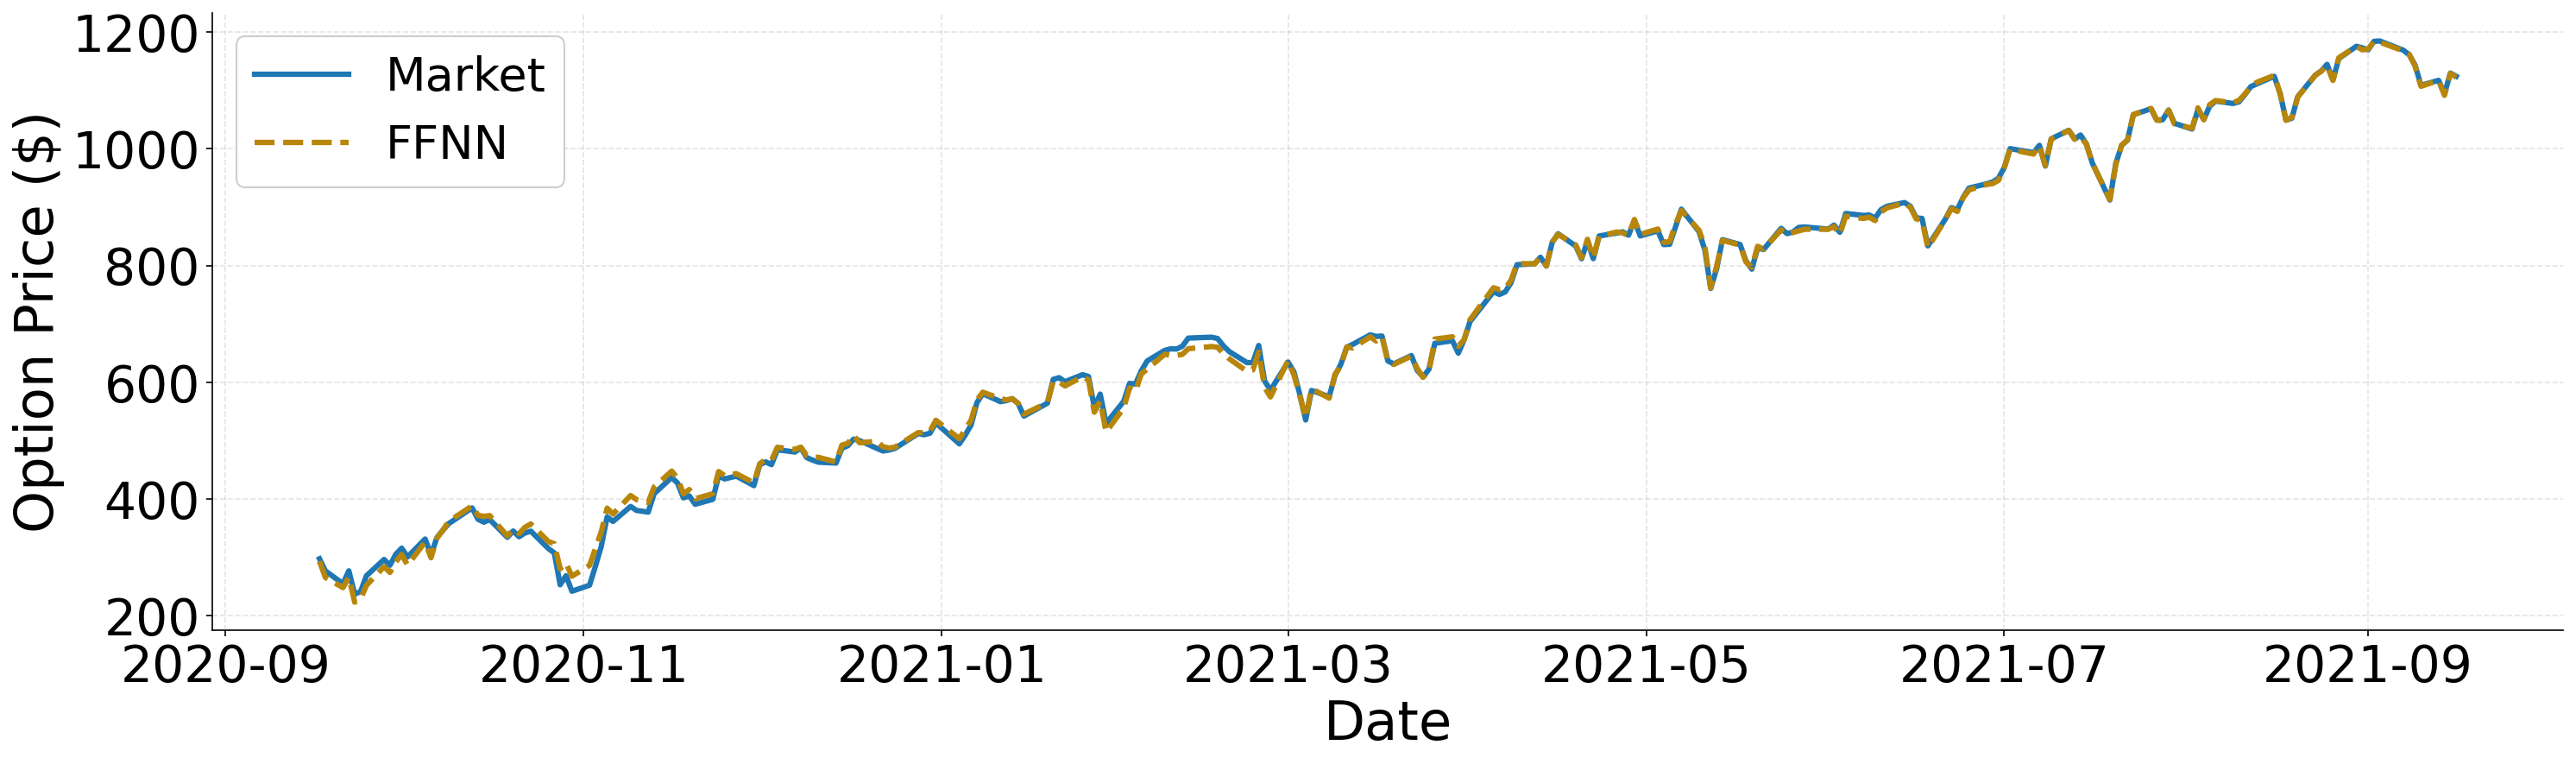

Saved PNG to: C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Results\long option\market_vs_ffnn_year_long_atm.png


In [79]:
# ------------------------------------------------------------------
# Market vs ML model plot (ATM, short-dated test option)
# ------------------------------------------------------------------
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ---- change these four for each model ----
MODEL_NAME_PRETTY = "FFNN"
MODEL_COLOUR      = "#B8860B"        # goldenrod
PRED              = pred_test_final  # test predictions from the cell above
FILE_TAG          = "ffnn"

print(PRED)

save_dir = Path(r"C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Results\long option")
save_dir.mkdir(parents=True, exist_ok=True)

plot_df = test_df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df["pred"] = pd.Series(PRED).values
plot_df = plot_df.sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(20, 6), dpi=150)

ax.plot(plot_df["date"], plot_df["mid"],
        linewidth=3, label="Market")
ax.plot(plot_df["date"], plot_df["pred"],
        linewidth=3, linestyle="--",
        color=MODEL_COLOUR, label=MODEL_NAME_PRETTY)

ax.set_xlabel("Date", fontsize=30)
ax.set_ylabel("Option Price ($)", fontsize=30)
ax.grid(True, which="major", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=28)

leg = ax.legend(frameon=True, fontsize=26, loc="best")
leg.get_frame().set_alpha(0.95)

plt.tight_layout()

png_path = save_dir / f"market_vs_{FILE_TAG}_year_long_atm.png"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved PNG to: {png_path}")

In [29]:
# ============================================================
# CELL A (REVISED): XGBoost using SAME splits + includes bs_price
# ============================================================

import numpy as np
from xgboost import XGBRegressor

# ----------------------------
# 0) XGBoost feature set
#    Use your existing FEATURES + add bs_price explicitly
# ----------------------------
XGB_FEATURES = FEATURES + ["bs_price"]

# ----------------------------
# 1) Build X/y from the SAME dataframes you already created
# ----------------------------
X_train_xgb = train_sub_df[XGB_FEATURES].copy()
y_train_xgb = train_sub_df["mid"].values

X_val_xgb   = val_df[XGB_FEATURES].copy()
y_val_xgb   = val_df["mid"].values

X_test_xgb  = test_df[XGB_FEATURES].copy()
y_test_xgb  = test_df["mid"].values

print("XGB train features preview:")
display(X_train_xgb.head())

# ----------------------------
# 2) Drop any non-finite rows (XGB can't handle NaN/inf)
# ----------------------------
def _finite_rows(dfX, y):
    m = np.isfinite(dfX.values).all(axis=1) & np.isfinite(y)
    return dfX.loc[m].copy(), y[m], m

X_train_xgb, y_train_xgb, m_tr = _finite_rows(X_train_xgb, y_train_xgb)
X_val_xgb,   y_val_xgb,   m_va = _finite_rows(X_val_xgb,   y_val_xgb)
X_test_xgb,  y_test_xgb,  m_te = _finite_rows(X_test_xgb,  y_test_xgb)

print("XGB shapes:", X_train_xgb.shape, X_val_xgb.shape, X_test_xgb.shape)

# ----------------------------
# 3) XGBoost model (your params)
# ----------------------------
xgb_model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=7,
    reg_alpha=0,
    reg_lambda=1.0,
    gamma=0.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=21,
    n_jobs=-1
)

print("Training XGBoost (direct mid, with bs_price feature)...")
xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False
)

mid_pred_xgb = xgb_model.predict(X_test_xgb)

print("XGBoost done.")


XGB train features preview:


,S,K,T,log_moneyness,sigma,r 3 Mo,bs_price
16604739,3768.5,3090.0,0.213699,0.198506,0.2857,0.0004,691.841306
13843746,3251.8,2830.0,0.336986,0.138932,0.2446,0.0013,460.139436
15052614,3271.0,3405.0,0.013699,-0.040149,0.4028,0.0010,17.257973
13603707,3009.1,2240.0,0.306849,0.295165,0.3473,0.0014,783.476498
17170963,4185.5,3110.0,0.095890,0.297003,0.1625,0.0002,1075.559643


XGB shapes: (160000, 7) (40000, 7) (54, 7)
Training XGBoost (direct mid, with bs_price feature)...
XGBoost done.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

=== Test Metrics (MID Price) ===
XGBoost (direct)   RMSE=2.7887 | MAE=2.2371 | MSE=7.7769
FFNN (BS+resid)    RMSE=1.8520 | MAE=1.5008 | MSE=3.4300


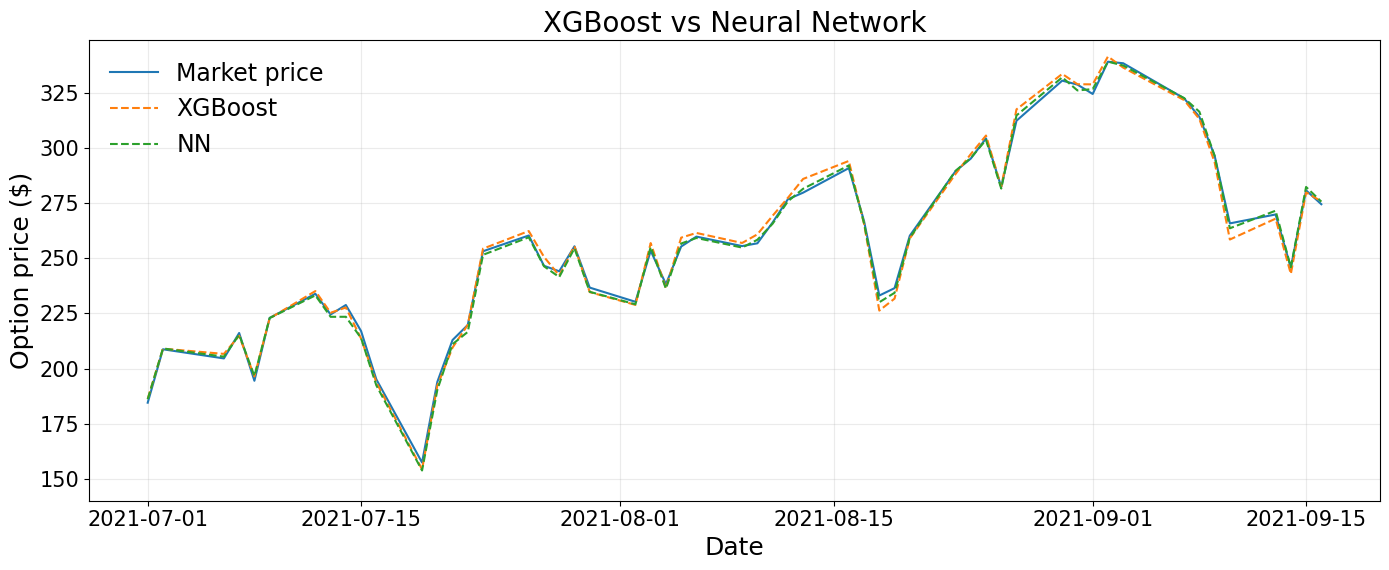

In [32]:
# ============================================================
# Compare: Market vs XGBoost vs FFNN (poster-ready)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ----------------------------
# 1) FFNN prediction (residual -> mid)
# ----------------------------
# Your FFNN uses scaled inputs X_test_s corresponding to test_df[FEATURES]
# If you dropped any rows from test_df for XGB, we need to align.
ffnn_res_pred_all = model.predict(X_test_s).ravel()
mid_pred_ffnn_all = test_df["bs_price"].values + ffnn_res_pred_all
mid_true_all      = test_df["mid"].values

# ----------------------------
# 2) Align arrays for fair comparison
#    XGB uses the finite mask m_te built in Cell A
# ----------------------------
# If you ran Cell A, m_te exists and indicates which test rows XGB used.
try:
    mid_true = mid_true_all[m_te]
    mid_pred_ffnn = mid_pred_ffnn_all[m_te]
except NameError:
    # fallback: assume no mask was created
    mid_true = mid_true_all
    mid_pred_ffnn = mid_pred_ffnn_all

# XGB outputs already correspond to the filtered test set (y_test_xgb / X_test_xgb)
mid_pred_xgb_aligned = mid_pred_xgb

# ----------------------------
# 3) Metrics
# ----------------------------
def _metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name:<18} RMSE={rmse:.4f} | MAE={mae:.4f} | MSE={mse:.4f}")
    return rmse, mae, mse

print("\n=== Test Metrics (MID Price) ===")
_ = _metrics(mid_true, mid_pred_xgb_aligned, "XGBoost (direct)")
_ = _metrics(mid_true, mid_pred_ffnn,        "FFNN (BS+resid)")

# ----------------------------
# 4) Poster-ready TIME SERIES plot (like BS vs Heston)
# ----------------------------

# Ensure we have aligned dates too
try:
    dates_all = pd.to_datetime(test_df["date"]).values
    dates = dates_all[m_te]
except NameError:
    dates = pd.to_datetime(test_df["date"]).values

# Sort by date (NOT by price)
order = np.argsort(dates)

plt.figure(figsize=(14, 5.8))

plt.plot(dates[order], mid_true[order], label="Market price", linewidth=1.5)
plt.plot(dates[order], mid_pred_xgb_aligned[order], label="XGBoost", linewidth=1.5, linestyle="--")
plt.plot(dates[order], mid_pred_ffnn[order], label="NN", linewidth=1.5, linestyle="--")

plt.title("XGBoost vs Neural Network", fontsize=20)
plt.xlabel("Date", fontsize=18)
plt.ylabel("Option price ($)", fontsize=18)
plt.tick_params(axis="both", which="major", labelsize=15)

plt.grid(True, alpha=0.25)
plt.legend(frameon=False, fontsize=17, loc="best")
plt.ylim(140, 349)
plt.tight_layout()
plt.savefig("xgb_vs_ffnn_timeseries.png", dpi=300)
plt.show()

